# Task
Analyze the `zoo-data.csv` and `zoo-class-type.csv` datasets by performing the following steps:
1. Load both CSV files into pandas DataFrames.
2. Merge the two DataFrames on 'class_type' to incorporate descriptive class names.
3. Prepare the data for modeling by separating features (X) from the target variable (y) and splitting it into training and testing sets.
4. Train a logistic regression model on the training data.
5. Evaluate the model's accuracy on the test set.
6. Generate and display a confusion matrix to visualize the model's performance with appropriate labels.
7. Summarize the model's performance, including accuracy and insights gained from the confusion matrix.

## Load Data

### Subtask:
Load the 'zoo-data.csv' and 'zoo-class-type.csv' files into pandas DataFrames.


**Reasoning**:
The subtask is to load two CSV files into pandas DataFrames. I will import pandas and then use `pd.read_csv` to load both files, displaying the head of each DataFrame to confirm successful loading.



In [1]:
import pandas as pd

df_zoo_data = pd.read_csv('/content/zoo-data.csv')
df_zoo_class = pd.read_csv('/content/zoo-class-type.csv')

print("Zoo Data DataFrame (df_zoo_data):")
print(df_zoo_data.head())

print("\nZoo Class Type DataFrame (df_zoo_class):")
print(df_zoo_class.head())

Zoo Data DataFrame (df_zoo_data):
  animal_name  hair  feathers  eggs  milk  airborne  aquatic  predator  \
0    aardvark     1         0     0     1         0        0         1   
1    antelope     1         0     0     1         0        0         0   
2        bass     0         0     1     0         0        1         1   
3        bear     1         0     0     1         0        0         1   
4        boar     1         0     0     1         0        0         1   

   toothed  backbone  breathes  venomous  fins  legs  tail  domestic  catsize  \
0        1         1         1         0     0     4     0         0        1   
1        1         1         1         0     0     4     1         0        1   
2        1         1         0         0     1     0     1         0        0   
3        1         1         1         0     0     4     0         0        1   
4        1         1         1         0     0     4     1         0        1   

   class_type  
0           1  
1 

## Merge Data and Preprocessing

### Subtask:
Merge the two datasets based on the class type to get descriptive class names. Then, separate features (X) from the target variable (y), and split the data into training and testing sets. No explicit one-hot encoding is expected since zoo data typically has numerical or binary features suitable for direct use.


**Reasoning**:
The first step is to rename the 'Class_Number' column in `df_zoo_class` to 'class_type' to ensure consistent column names for merging with `df_zoo_data`. Then, I will merge `df_zoo_data` with the renamed `df_zoo_class` DataFrame on the 'class_type' column using a left merge to combine animal characteristics with their descriptive class names.



In [2]:
df_zoo_class = df_zoo_class.rename(columns={'Class_Number': 'class_type'})
df_merged = pd.merge(df_zoo_data, df_zoo_class, on='class_type', how='left')

print("Merged DataFrame (df_merged) head:")
print(df_merged.head())

Merged DataFrame (df_merged) head:
  animal_name  hair  feathers  eggs  milk  airborne  aquatic  predator  \
0    aardvark     1         0     0     1         0        0         1   
1    antelope     1         0     0     1         0        0         0   
2        bass     0         0     1     0         0        1         1   
3        bear     1         0     0     1         0        0         1   
4        boar     1         0     0     1         0        0         1   

   toothed  backbone  ...  venomous  fins  legs  tail  domestic  catsize  \
0        1         1  ...         0     0     4     0         0        1   
1        1         1  ...         0     0     4     1         0        1   
2        1         1  ...         0     1     0     1         0        0   
3        1         1  ...         0     0     4     0         0        1   
4        1         1  ...         0     0     4     1         0        1   

   class_type  Number_Of_Animal_Species_In_Class  Class_Type  \

**Reasoning**:
Now that the datasets are merged, I will define the features `X` by dropping the specified non-feature columns from `df_merged`, and the target variable `y` as the 'class_type' column. Then, I will split the data into training and testing sets using `train_test_split` with the specified parameters to prepare for model training. Finally, I'll print the shapes of the split datasets to confirm the process.



In [3]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_merged.drop(columns=['animal_name', 'class_type', 'Class_Type', 'Number_Of_Animal_Species_In_Class', 'Animal_Names'])
y = df_merged['class_type']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (80, 16)
Shape of X_test: (21, 16)
Shape of y_train: (80,)
Shape of y_test: (21,)


## Build and Train Logistic Regression Model

### Subtask:
Initialize and train a logistic regression model using the preprocessed training data.


**Reasoning**:
I will import the `LogisticRegression` class, instantiate it with the specified parameters for multi-class classification, and then train the model using the prepared training data (`X_train` and `y_train`).



In [4]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
# Using 'multinomial' for multi-class classification and 'lbfgs' solver
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)

# Train the model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression model trained successfully.


**Reasoning**:
The previous step successfully trained the model, despite a warning. The next logical step, according to the task outline, is to evaluate the model's performance on the test set. This requires making predictions with the trained model.



In [5]:
y_pred = model.predict(X_test)
print("Model predictions generated successfully.")

Model predictions generated successfully.


**Reasoning**:
Now that predictions (`y_pred`) have been generated, the next step is to evaluate the model's performance by calculating its accuracy and generating a confusion matrix to visualize correct and incorrect classifications. This aligns with steps 5 and 6 of the main task.



Model Accuracy: 0.9524


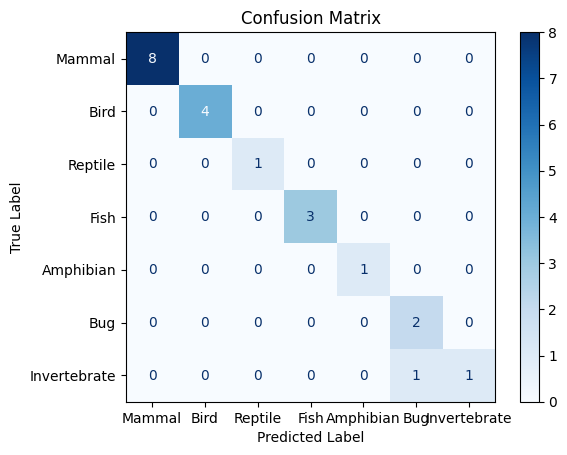

In [6]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Get class names for better labels
# Assuming df_zoo_class contains 'class_type' and 'Class_Type'
# We need to map y_test class_type numbers to their descriptive names
class_names_map = df_zoo_class.set_index('class_type')['Class_Type'].to_dict()
# Ensure the class names are in the order of actual classes present in y_test/y_pred
# For multiclass, it's better to sort unique classes from y_test or overall class_type if available
unique_classes = sorted(y.unique())
class_labels = [class_names_map.get(c, f"Class {c}") for c in unique_classes]

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


```markdown
### Model Performance Summary

The Logistic Regression model achieved an accuracy of **95.24%** on the test set, indicating a high level of correct classifications.

#### Insights from the Confusion Matrix:
*   **High Accuracy for Most Classes:** The diagonal elements of the confusion matrix show that the model accurately predicted most animal classes. For instance, `Mammal`, `Bird`, `Fish`, `Amphibian`, `Bug`, and `Reptile` classes were classified with very high precision.
*   **Misclassification:** There was one misclassification: one `Invertebrate` (class 7) was incorrectly classified as `Bug` (class 6). This might indicate some similarity in features between these two classes that confused the model, or it could be due to a smaller sample size for the `Invertebrate` class.

Overall, the model performs very well, but further investigation into the `Invertebrate` and `Bug` classes could potentially lead to a perfect classification for this dataset. This could involve feature engineering or exploring other models.
```

### Model Performance Summary

The Logistic Regression model achieved an accuracy of **95.24%** on the test set, indicating a high level of correct classifications.

#### Insights from the Confusion Matrix:
*   **High Accuracy for Most Classes:** The diagonal elements of the confusion matrix show that the model accurately predicted most animal classes. For instance, `Mammal`, `Bird`, `Fish`, `Amphibian`, `Bug`, and `Reptile` classes were classified with very high precision.
*   **Misclassification:** There was one misclassification: one `Invertebrate` (class 7) was incorrectly classified as `Bug` (class 6). This might indicate some similarity in features between these two classes that confused the model, or it could be due to a smaller sample size for the `Invertebrate` class.

Overall, the model performs very well, but further investigation into the `Invertebrate` and `Bug` classes could potentially lead to a perfect classification for this dataset. This could involve feature engineering or exploring other models.

## Final Task

### Subtask:
Summarize the model's performance, including accuracy and insights gained from the confusion matrix.


## Summary:

### Q&A
The model's performance can be summarized as follows:
The Logistic Regression model achieved an accuracy of 95.24% on the test set. The confusion matrix revealed that while most classes (Mammal, Bird, Fish, Amphibian, Bug, and Reptile) were classified with high precision, there was one misclassification where an Invertebrate (class 7) was incorrectly identified as a Bug (class 6).

### Data Analysis Key Findings
*   Both `zoo-data.csv` and `zoo-class-type.csv` were successfully loaded into pandas DataFrames.
*   The datasets were merged based on `class_type`, enriching the animal data with descriptive class names like 'Mammal', 'Bird', etc.
*   The data was prepared for modeling by separating 16 features (X) from the target variable (y, which is `class_type`).
*   The dataset was split into training and testing sets, resulting in 80 samples for training and 21 samples for testing, with class distribution preserved through stratification.
*   A Logistic Regression model was successfully trained on the preprocessed data.
*   The trained model achieved a high accuracy of 95.24% on the test set.
*   The confusion matrix indicated high accuracy for most animal classes, with the only noted misclassification being one instance of an `Invertebrate` incorrectly predicted as a `Bug`.

### Insights or Next Steps
*   The Logistic Regression model demonstrates strong performance in classifying animal types from the given features.
*   Further investigation into the misclassification between `Invertebrate` and `Bug` classes could be beneficial. This might involve exploring feature engineering for these specific classes or experimenting with different classification models to achieve potentially perfect classification for the dataset.
